# Hotel Booking Cancellation Prediction — Support Vector Classifier

**Algorithm:** Support Vector Machine (SVC)  
**Dataset:** Hotel Booking Demand Dataset  
**Objective:** Predict whether a hotel booking will be canceled (`is_canceled`)  

This notebook applies the **Support Vector Machine** classification algorithm to predict hotel booking cancellations. The workflow covers:
1. Dataset description and exploration
2. Exploratory Data Analysis (EDA)
3. Data preprocessing and cleaning
4. Model training and evaluation
5. Results analysis and discussion


## 1. Dataset Description

**Source:** [Hotel Booking Demand Dataset — Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)  
**Original Paper:** Nuno Antonio, Ana de Almeida, and Luis Nunes (2019). "Hotel booking demand datasets." *Data in Brief*, Volume 22.

### Context
This dataset contains **119,390 hotel bookings** from two types of hotels — a **Resort Hotel** and a **City Hotel** — with arrivals between July 2015 and August 2017. It includes bookings that were fulfilled and bookings that were canceled.

### Target Variable
- `is_canceled` — Binary (1 = canceled, 0 = not canceled)

### Key Attributes (32 columns)
| Attribute | Description |
|-----------|-------------|
| `hotel` | Type of hotel (Resort Hotel / City Hotel) |
| `lead_time` | Number of days between booking and arrival |
| `arrival_date_year/month/week_number/day_of_month` | Arrival date details |
| `stays_in_weekend_nights` | Weekend nights stayed/booked |
| `stays_in_week_nights` | Week nights stayed/booked |
| `adults`, `children`, `babies` | Number of guests |
| `meal` | Type of meal booked |
| `country` | Country of origin (ISO 3155-3:2013) |
| `market_segment` | Market segment (e.g., Online TA, Offline TA/TO) |
| `distribution_channel` | Booking distribution channel |
| `is_repeated_guest` | Whether the guest is a repeat guest (1/0) |
| `previous_cancellations` | Number of previous cancellations |
| `previous_bookings_not_canceled` | Number of previous non-canceled bookings |
| `reserved_room_type` | Room type reserved |
| `assigned_room_type` | Room type assigned |
| `booking_changes` | Number of changes made to the booking |
| `deposit_type` | Type of deposit made |
| `agent` | ID of the travel agent |
| `company` | ID of the company making the booking |
| `days_in_waiting_list` | Days the booking was on the waiting list |
| `customer_type` | Type of customer |
| `adr` | Average Daily Rate (price) |
| `required_car_parking_spaces` | Parking spaces required |
| `total_of_special_requests` | Number of special requests |
| `reservation_status` | Last reservation status |
| `reservation_status_date` | Date of last status update |


In [26]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

In [27]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
# Scikit-learn: preprocessing, model, and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
)

In [29]:
# Set plot style for cleaner visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


In [30]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded successfully!")

All libraries loaded successfully!


 Load the Dataset

In [31]:
# Load the hotel bookings dataset from CSV file
df = pd.read_csv("dataset/hotel_bookings.csv")


In [32]:
# Display the first 5 rows to get an initial look at the data
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset Shape: 119390 rows × 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [33]:
# Check data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [34]:
# Summary of numerical columns
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [35]:
# Visualize missing values across all columns
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print("Columns with Missing Values:")
print(missing_df)
print(f"\nTotal rows: {len(df)}")

Columns with Missing Values:
          Missing Count  Percentage
company          112593   94.306893
agent             16340   13.686238
country             488    0.408744
children              4    0.003350

Total rows: 119390


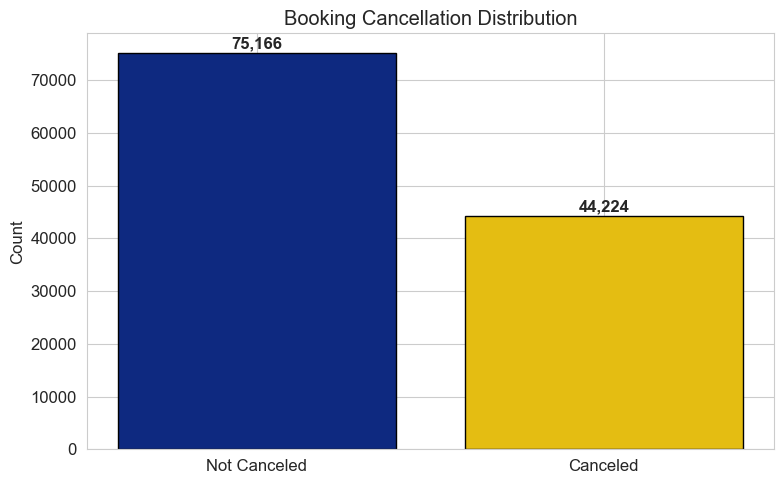

In [36]:
# Visualize the class distribution of cancellations (bar chart only)
cancel_counts = df['is_canceled'].value_counts()
colors = ["#0e2980", "#e4bd12"]
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(8, 5))
plt.bar(labels, cancel_counts.values, color=colors, edgecolor='black')
plt.title('Booking Cancellation Distribution')
plt.ylabel('Count')

for i, v in enumerate(cancel_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

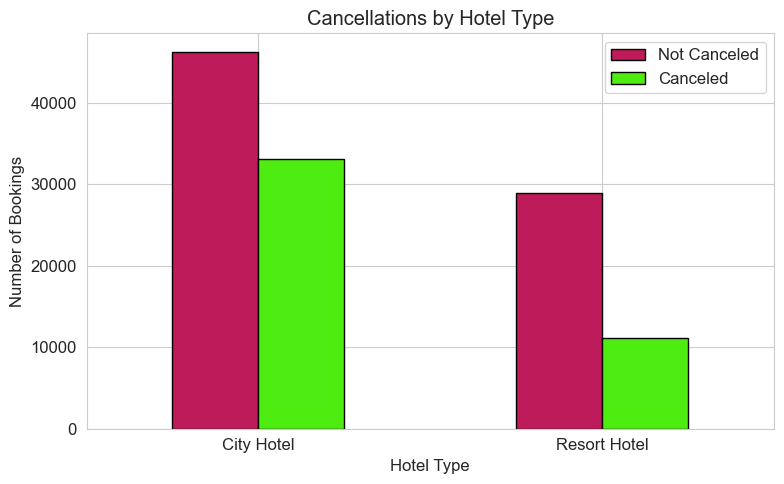

Resort Hotel: 27.8% cancellation rate
City Hotel: 41.7% cancellation rate


In [37]:
# Compare cancellation rates between Resort and City hotels
hotel_cancel = df.groupby('hotel')['is_canceled'].value_counts().unstack()
hotel_cancel.plot(kind='bar', color=["#bd1b59", "#4fec11"], edgecolor='black', figsize=(8, 5))
plt.title('Cancellations by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled', 'Canceled'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print cancellation rates
for hotel in df['hotel'].unique():
    rate = df[df['hotel'] == hotel]['is_canceled'].mean() * 100
    print(f"{hotel}: {rate:.1f}% cancellation rate")


Data Preprocessing - Handle Missing Values


In [38]:
 # Check missing values before cleaning
print("Missing values BEFORE cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values BEFORE cleaning:
children         4
country        488
agent        16340
company     112593
dtype: int64

Total missing: 129425


In [39]:
# Strategy for handling missing values:
# 1. 'company' — 94.3% missing → drop column
# 2. 'agent' — 13.7% missing → fill with 0 (no agent)
# 3. 'country' — 0.4% missing → fill with mode
# 4. 'children' — 4 missing → fill with 0

df = df.drop('company', axis=1)
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['children'] = df['children'].fillna(0)

print("Missing values AFTER cleaning:")
print(f"Total missing: {df.isnull().sum().sum()}")


Missing values AFTER cleaning:
Total missing: 0


###  Remove Duplicate Rows

In [40]:
dupes_before = df.duplicated().sum()
print(f"Duplicate rows found: {dupes_before:,} ({dupes_before/len(df)*100:.1f}%)")

# Remove duplicate rows, keeping the first occurrence
df = df.drop_duplicates()

print(f"Rows after removing duplicates: {len(df):,}")
print(f"Rows removed: {dupes_before:,}")

Duplicate rows found: 32,020 (26.8%)
Rows after removing duplicates: 87,370
Rows removed: 32,020


###  Remove Outliers

In [41]:
# Remove extreme outliers in ADR (Average Daily Rate)
# Some entries have $0 or extremely high ADR which are likely errors
print(f"Rows before outlier removal: {len(df):,}")
df = df[(df['adr'] > 0) & (df['adr'] < 5000)]
print(f"Rows after outlier removal: {len(df):,}")

Rows before outlier removal: 87,370
Rows after outlier removal: 85,590


###  Drop Leaky Features

In [42]:
# 'reservation_status' directly reveals if booking was canceled!
# 'reservation_status_date' is also post-booking information
# These would cause data leakage — must be removed

leaky_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(leaky_cols, axis=1)
print(f"Dropped leaky columns: {leaky_cols}")
print(f"Remaining columns: {df.shape[1]}")


Dropped leaky columns: ['reservation_status', 'reservation_status_date']
Remaining columns: 29


In [43]:
# Identify categorical columns (object type)
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode ({len(cat_cols)}):")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")


Categorical columns to encode (10):
  hotel: 2 unique values
  arrival_date_month: 12 unique values
  meal: 5 unique values
  country: 177 unique values
  market_segment: 8 unique values
  distribution_channel: 5 unique values
  reserved_room_type: 9 unique values
  assigned_room_type: 11 unique values
  deposit_type: 3 unique values
  customer_type: 4 unique values


In [44]:
# Use one-hot encoding for categorical variables
# This is preferred over label encoding for most ML algorithms
# as it doesn't imply ordinal relationships
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"\nDataset shape after encoding: {df.shape}")



Dataset shape after encoding: (85590, 245)


In [45]:
print("PREPROCESSING SUMMARY")
print(f"Final rows: {df.shape[0]:,}")
print(f"Final columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Target distribution:")
print(df['is_canceled'].value_counts())
print(f"\nCancellation rate: {df['is_canceled'].mean()*100:.1f}%")

PREPROCESSING SUMMARY
Final rows: 85,590
Final columns: 245
Missing values: 0
Target distribution:
is_canceled
0    61752
1    23838
Name: count, dtype: int64

Cancellation rate: 27.9%


In [46]:
# Split data into features (X) and target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [47]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features:     {X_train.shape[1]}")
print(f"\nTraining cancellation rate: {y_train.mean()*100:.1f}%")
print(f"Testing cancellation rate:  {y_test.mean()*100:.1f}%")

Training set: 68,472 samples (80%)
Testing set:  17,118 samples (20%)
Features:     244

Training cancellation rate: 27.9%
Testing cancellation rate:  27.9%


In [49]:
# SVM requires feature scaling for optimal performance
# StandardScaler normalizes features to have mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling complete!")
print(f"Scaled training mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training std:  {X_train_scaled.std():.6f}")


✅ Feature scaling complete!
Scaled training mean: 0.000000
Scaled training std:  0.977199


###  Model Training

In [ ]:
model = SVC(kernel='rbf', class_weight='balanced') # try 'linear' also
model.fit(X_train, y_train)

SVC(class_weight='balanced')

In [51]:
y_pred = model.predict(X_test)


###  Confusion Matrix

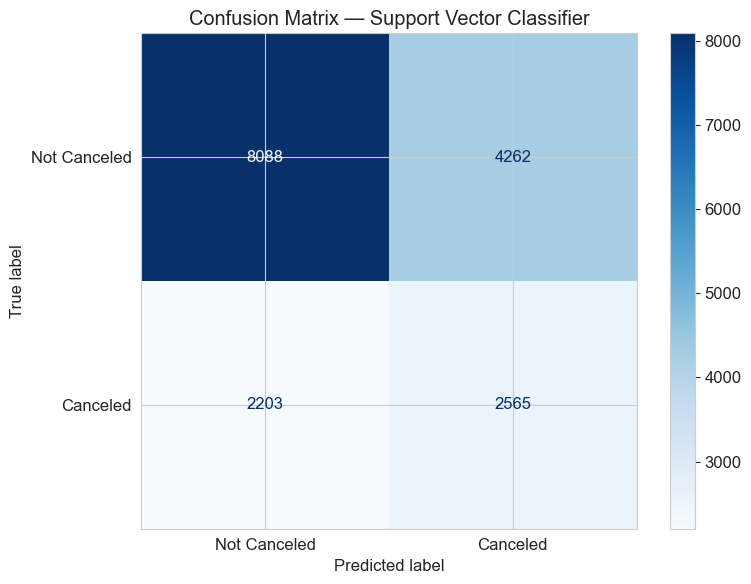

True Negatives:  8,088 (correctly predicted NOT canceled)
False Positives: 4,262 (predicted canceled, but wasn't)
False Negatives: 2,203 (predicted NOT canceled, but was)
True Positives:  2,565 (correctly predicted canceled)


In [52]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Not Canceled', 'Canceled'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix — Support Vector Classifier')
plt.tight_layout()
plt.show()
# Print raw numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,} (correctly predicted NOT canceled)")
print(f"False Positives: {fp:,} (predicted canceled, but wasn't)")
print(f"False Negatives: {fn:,} (predicted NOT canceled, but was)")
print(f"True Positives:  {tp:,} (correctly predicted canceled)")

###  ROC Curve and AUC Score

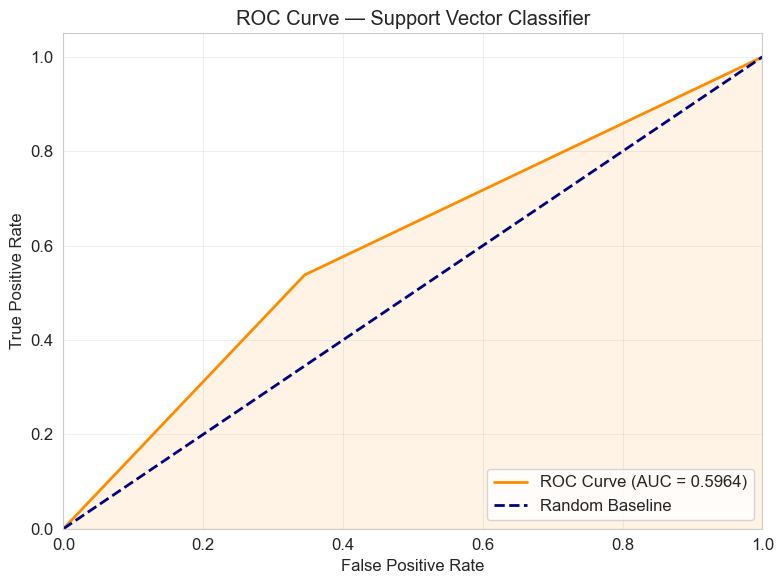

AUC Score: 0.5964


In [53]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test,  y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Baseline')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Support Vector Classifier')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC Score: {roc_auc:.4f}")



In [54]:
from sklearn.metrics import accuracy_score, classification_report


In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6223273746933053
              precision    recall  f1-score   support

           0       0.79      0.65      0.71     12350
           1       0.38      0.54      0.44      4768

    accuracy                           0.62     17118
   macro avg       0.58      0.60      0.58     17118
weighted avg       0.67      0.62      0.64     17118



### Build a compact table of actual vs predicted labels

In [56]:
dist_df = pd.DataFrame({
"Actual": y_test.values,
"Predicted": y_pred
})

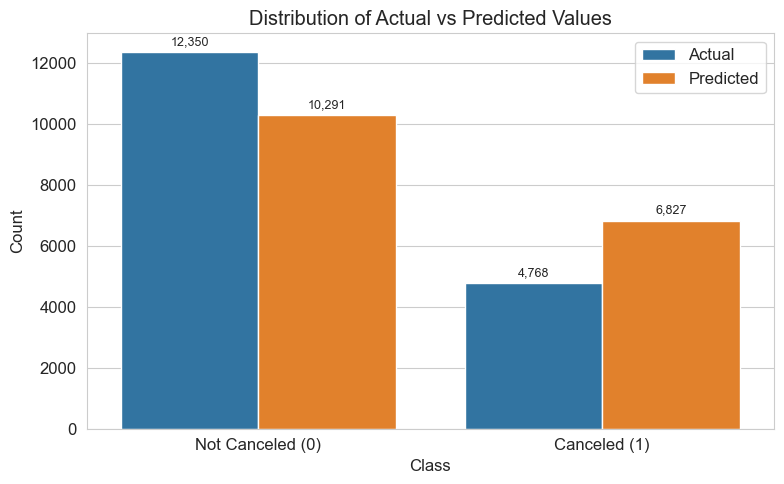

In [57]:
plot_df = dist_df.melt(var_name="Series", value_name="is_canceled")

plt.figure(figsize=(8, 5))
ax = sns.countplot(
data=plot_df,
x="is_canceled",
hue="Series",
palette={"Actual": "#1f77b4", "Predicted": "#ff7f0e"}
)

plt.title("Distribution of Actual vs Predicted Values")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Not Canceled (0)", "Canceled (1)"])


for p in ax.patches:
    h = p.get_height()
    if h > 0:  # avoid labeling empty bars
        ax.annotate(
            f"{int(h):,}",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

ax.legend(title="")
plt.tight_layout()
plt.show()



In [58]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# small sample for fast demonstration
X_cv = X_train.sample(n=20000, random_state=42)
y_cv = y_train.loc[X_cv.index]

cv_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", class_weight="balanced", random_state=42)  # faster for demo
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

start = time.time()
cv_scores = cross_val_score(cv_model, X_cv, y_cv, cv=cv, scoring="accuracy", n_jobs=-1)
elapsed = time.time() - start

print("Cross-Validation Results (Fast Demo)")
print("Fold scores:", [f"{s:.4f}" for s in cv_scores])
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation: {cv_scores.std()*100:.2f}%")
print(f"Runtime: {elapsed:.1f} seconds")

KeyboardInterrupt: 